# Assignment 2 — Regression and Classification: Error Analysis

**Holon Institute of Technology (HIT) — Faculty of Computer Science**

| | |
|---|---|
| **Course** | Introduction to Data Science |
| **Assignment** | 2 — Regression and Classification: Error Analysis |
| **Student name** | Sean Mazon |
| **ID number** | 212234660 |
| **Lecturer** | Dr. Uri Itai |
| **Teaching assistant** | Hanit Ohayon Hadad |
| **Submission deadline** | 10.09.2026 |

---

## Table of Contents

0. [Introduction](#0-introduction)
1. [Data Preparation](#1-data-preparation)
2. [Regression Error Analysis](#2-regression-error-analysis)
3. [Regression Models](#3-regression-models)
4. [Classification Error Analysis](#4-classification-error-analysis)
5. [Final Reflection](#5-final-reflection)

## 0. Introduction

This chapter sets out what the assignment asks for, what data the analysis is
built on, and which parts of the setup are prescribed by the assignment as
opposed to chosen here. It contains no code and no results; the analysis begins
in chapter 1.

### 0.1 Objective

The assignment defines its own purpose as developing an understanding of
regression and classification models **through systematic error analysis**, and
asks students to distinguish between failures that arise from data issues, from
model assumptions, and from how the problem was formulated.

That framing determines how this notebook is written. **Predictive accuracy is
not the goal.** A model that scored well but whose errors could not be
explained would fail the assignment, while a model that performs modestly and
whose failures are understood would satisfy it. Every metric reported here
exists to support a statement about *why* the model is wrong where it is wrong.

The assignment prescribes four things, and they are the fixed points of this
notebook:

1. The four analytical sections and their sub-tasks — residual analysis, error
   as a function of features, extreme errors, statistical properties of errors,
   the regression model comparison, the classification error analysis, and the
   final reflection.
2. Three families of regression model: linear, decision tree, and at least one
   ensemble.
3. That **all analyses be conducted using k-fold cross-validation**.
4. That the choice of *k* be justified in terms of dataset size, computational
   complexity, and the bias–variance trade-off.

Everything else — which dataset, which target variables, which features, which
classifiers — is not specified by the assignment. Those are decisions taken
here, and each one is identified as such and justified where it is made.

### 0.2 Dataset Overview

The assignment does not supply or name a dataset. This analysis continues with
the dataset used in Assignment 1: **1,500 of the highest-revenue games released
on Steam during 2024**, obtained from Kaggle and extracted on 2024-09-09. The
file holds 1,500 rows and 11 columns, mixing numeric, temporal and categorical
variables.

Using the same data is a deliberate choice. Assignment 1 established a set of
findings about its structure that directly constrain any model built on it, and
carrying those forward is more informative than rediscovering them:

| Finding from Assignment 1 | Consequence for this assignment |
|---|---|
| `reviewScore = 0` is a placeholder in 99 rows, `avgPlaytime = 0` in one | Must become missing values, then be imputed **inside** the cross-validation folds |
| `revenue` is extremely heavy-tailed (skew 22.9; 1.19 after a log transform) | Motivates the regression target chosen in 0.3 |
| `publishers` and `developers` hold 1,169 and 1,517 distinct companies | Cannot be one-hot encoded; must be aggregated into numeric features |
| `publisherClass` has a single `Hobbyist` row | Merged into `Indie`, leaving three ordered levels |
| Three missing cells, all in the company fields | Imputation strategy needed, though the volume is negligible |
| The rows were selected *because* revenue was high | The most important caveat in this notebook — see below |

**The survivorship caveat, stated at the outset.** These 1,500 games were
selected on revenue, which is the same quantity this notebook sets out to
predict and to classify. Every result that follows therefore describes the
behaviour of models *within an already-successful population*, never across
Steam as a whole. Statements such as "the model predicts commercial success"
must be read as "the model separates the strongest performers from the
moderately strong ones". This is not a limitation discovered at the end of the
analysis; it is a property of the sample and it is carried through every
chapter.

The full structural analysis of this dataset is in the Assignment 1 notebook,
`assignment1-eda/notebooks/steam_2024_eda.ipynb`.

### 0.3 Problem Definitions

**The assignment specifies neither a regression target nor a classification
target.** Both are defined here, and both are methodological choices rather than
requirements. Each is justified in full in chapter 1, where the supporting
evidence is computed; the definitions are stated here so the rest of the
notebook can refer to them.

#### Regression problem

> Predict **`log10(revenue)`** — the base-10 logarithm of a game's estimated
> revenue in US dollars.

The logarithm is used because Assignment 1 measured a skew of 22.9 on the raw
values against 1.19 after the transform. Residual analysis on the raw scale
would be dominated by a handful of titles and would make the questions in
section 2.1 — about centring, systematic pattern and heteroscedasticity —
effectively unanswerable. Metrics are also reported back on the original dollar
scale so that the error magnitudes remain interpretable.

#### Classification problem

> Predict whether a game is a **commercial standout**, defined as
> `revenue` at or above the 75th percentile of the dataset.

This yields roughly 375 positive and 1,125 negative cases. A threshold at the
median would produce a balanced problem, but a 25/75 split is the more
informative choice for what section 3 of the assignment asks: it gives the
precision–recall trade-off something to trade, and it makes the threshold sweep
and the Matthews correlation coefficient meaningful rather than near-symmetric.

The two error types also carry genuinely different costs in the underlying
decision problem, which section 4.2 develops. A false positive corresponds to
backing a title that does not deliver; a false negative corresponds to passing
on one that would have. The threshold is a fixed definitional choice computed
once on the full dataset, not a quantity learned from the data.

#### A note on the feature set

The features are **not fixed at this point**. Assignment 1 found that `revenue`,
`copiesSold` and `price` are tightly linked, which raises the possibility that
including `copiesSold` as a predictor would make both problems trivial and leave
no error structure to analyse. Section 1 tests that empirically and decides the
feature set on the evidence, rather than assuming the answer here.

### 0.4 Methodology

Each analytical section follows the same four-part pattern:

- **Method** — what is being done and why.
- **Results** — the metrics, tables and figures.
- **Interpretation** — what the results mean, including where they contradict
  what was expected.
- **Conclusion** — the single insight the section establishes.

Two rules govern the writing. First, **interpretations are written after the
results are read**, never drafted in advance; where an outcome is surprising it
is reported as surprising rather than smoothed over. Second, **evidence and
hypothesis are kept distinct**: where the data shows a pattern but cannot
establish its cause, the proposed cause is labelled as a hypothesis and the
information that would test it is named.

Chapter 3 of the assignment requires three families of regression model. This
notebook uses Linear Regression, a Decision Tree Regressor, and a **Random
Forest Regressor** as the ensemble. All three are trained on an identical
feature set under an identical resampling protocol, so that differences in
performance are attributable to the models rather than to their inputs.

For the classification analysis the assignment names no model. Two are used
here — **Logistic Regression** and a **Random Forest Classifier** — because the
discussion section calls for a comparison, and a comparison needs more than one
subject. This is a choice, not a requirement.

### 0.5 Cross-Validation Strategy

The assignment requires that **all** analyses use k-fold cross-validation. That
requirement is stated in its objective rather than in the modelling section, so
it governs the error analysis as much as the model comparison: the residuals
examined in chapter 2 and the confusion matrix in chapter 4 must not be computed
from predictions the model made on data it was trained on.

The protocol used throughout is therefore:

- **Out-of-fold prediction.** Every observation receives a prediction from a
  model that never saw it during training. Pooling these across folds yields one
  prediction per row, which is what the residual analysis, the extreme-error
  analysis and the confusion matrix are built from.
- **k = 10**, with shuffling and a fixed random seed. The justification in terms
  of dataset size, computational cost and the bias–variance trade-off is given
  in section 1, where it can be supported with the actual dimensions of the data
  rather than asserted here.
- **Stratified folds for classification**, so that the 25/75 class balance is
  preserved in every fold and the per-fold metrics remain comparable.
- **Pipelines for all preprocessing.** Imputation, scaling and encoding are
  fitted on the training portion of each fold only. Fitting them on the full
  dataset first — the most common source of leakage in cross-validated work —
  would let information from the held-out fold influence the transformation
  applied to it.

Section 1 sets this protocol up and states explicitly what each element
prevents.

## 1. Data Preparation

**Method.** This chapter assembles the data the rest of the notebook depends on
and settles three questions before any model is compared: which features the
models may see, how many folds to use, and how preprocessing is prevented from
leaking information between them. Each is decided from measurements on this
dataset rather than by convention.

### 1.1 Loading and Cleaning

The cleaning established in Assignment 1 is imported rather than rewritten, so
that both notebooks treat the data identically. It converts the placeholder
zeros in `reviewScore` and `avgPlaytime` into missing values, parses the release
date, orders `publisherClass`, and merges the single `Hobbyist` row into `Indie`.

Critically, the placeholders become **missing values rather than imputed
values** at this stage. Imputation belongs inside the cross-validation folds,
for the reason set out in section 1.5.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, StratifiedKFold

# The helper package for this assignment sits one level above the notebook. It
# in turn adds Assignment 1's package to the path, so the cleaning defined there
# can be reused unchanged.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from error_analysis.data_setup import (
    ALL_FEATURES,
    BOOLEAN_FEATURES,
    CATEGORICAL_FEATURES,
    CLASSIFICATION_TARGET,
    NUMERIC_FEATURES,
    REGRESSION_TARGET,
    STANDOUT_QUANTILE,
    WITHHELD_COLUMNS,
    build_modelling_frame,
    build_pipeline,
    describe_feature_roles,
)
from error_analysis.validation import (
    RANDOM_STATE,
    compare_feature_sets,
    compare_fold_counts,
    regression_metrics,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

games = build_modelling_frame()

print(f"Rows: {len(games):,}    Columns available after derivation: {games.shape[1]}")
print()
print("Missing values in the candidate feature matrix:")
print(games[ALL_FEATURES].isna().sum().loc[lambda counts: counts > 0].to_string())

Rows: 1,500    Columns available after derivation: 30

Missing values in the candidate feature matrix:
reviewScore    99
avgPlaytime     1


**Results and interpretation.** The frame holds all 1,500 games. Two feature
columns carry missing values, and both are the placeholders identified in
Assignment 1 rather than genuine gaps in the source file: 99 review scores that
were stored as `0`, and one average playtime. No rows are dropped — discarding
99 games because their review score is unknown would remove 6.6% of the data and,
as Assignment 1 showed, that group is not a random sample of the whole.

### 1.2 Feature and Target Definition

**Method.** The assignment specifies neither targets nor features. Both are
defined here, and the same feature set is used for every model and for both
problems, which is what makes the comparison in chapter 3 a fair one.

In [2]:
display(describe_feature_roles())

standout_threshold = games["revenue"].quantile(STANDOUT_QUANTILE)
class_counts = games[CLASSIFICATION_TARGET].value_counts().sort_index()

print(f"Regression target      : {REGRESSION_TARGET}  "
      f"(range {games[REGRESSION_TARGET].min():.2f} to {games[REGRESSION_TARGET].max():.2f}, "
      f"sd {games[REGRESSION_TARGET].std():.2f})")
print(f"Classification target  : {CLASSIFICATION_TARGET} = revenue >= ${standout_threshold:,.0f} "
      f"({STANDOUT_QUANTILE:.0%} percentile)")
print(f"Class balance          : {class_counts[1]} standouts / {class_counts[0]} others "
      f"({games[CLASSIFICATION_TARGET].mean():.1%} positive)")

,Feature,Type,Why it is included
0,price,numeric,Listed price; the strongest legitimate predict...
1,reviewScore,numeric,"Percentage of positive reviews, after placehol..."
2,avgPlaytime,numeric,"Average hours played, a proxy for engagement"
3,daysOnSale,numeric,Exposure at the snapshot date
4,publisherReleaseCount,numeric,How many titles the publisher has in this dataset
5,releaseMonth,numeric,Calendar month of release
6,plotClass,categorical,"Studio scale: Indie, AA or AAA"
7,releaseWeekday,categorical,Day of the week the title launched
8,selfPublished,boolean,Whether publisher and developer are the same c...
9,isFreeToPlay,boolean,Whether the listed price is zero


Regression target      : logRevenue  (range 4.32 to 8.92, sd 0.75)
Classification target  : isStandout = revenue >= $455,157 (75% percentile)
Class balance          : 375 standouts / 1125 others (25.0% positive)


**Interpretation.** Ten features are available to every model: six numeric, two
categorical and two boolean.

`log10(revenue)` spans 4.32 to 8.92 with a standard deviation of 0.75, which
means the target covers more than four orders of magnitude on the dollar scale.
The classification threshold falls at **$455,157**, giving 375 standouts against
1,125 others — the 25/75 split chosen in section 0.3.

**One feature carries a caveat that should be stated rather than buried.**
`publisherReleaseCount` counts how many titles a publisher has *in this dataset*,
and this dataset was selected on revenue. A studio therefore appears often partly
because it had several commercially successful releases, so the feature carries a
faint trace of the target. Its rank correlation with `log10(revenue)` is only
0.12, so the effect is weak, but it is not zero and it is worth remembering when
this feature appears in the error analysis.

### 1.3 Testing for Target Leakage

**Method.** Assignment 1 found `revenue`, `copiesSold` and `price` to be closely
linked, which raises a question that has to be settled before any model is built:
would including `copiesSold` as a predictor leave any error structure to analyse?

The question is answered in two steps rather than assumed. First, the strength of
the relationship is measured directly. Second, the identical Linear Regression is
run under the identical protocol twice, changing only whether `copiesSold` is
available to it.

In [3]:
correlation_rows = []
for column in ["copiesSold", "price", "avgPlaytime", "reviewScore", "daysOnSale",
               "publisherReleaseCount"]:
    subset = games[[column, REGRESSION_TARGET]].dropna()
    values = np.log10(subset[column]) if column == "copiesSold" else subset[column]
    correlation_rows.append({
        "Feature": f"log10({column})" if column == "copiesSold" else column,
        "Pearson vs log10(revenue)": round(pearsonr(values, subset[REGRESSION_TARGET])[0], 3),
        "Spearman": round(spearmanr(values, subset[REGRESSION_TARGET])[0], 3),
    })
display(pd.DataFrame(correlation_rows))

# If revenue were simply copies multiplied by price, regressing the logarithms
# against each other would recover coefficients of 1.0 and an R2 close to 1.
paid_games = games[games["price"] > 0]
identity_features = pd.DataFrame({
    "log10(copiesSold)": np.log10(paid_games["copiesSold"]),
    "log10(price)": np.log10(paid_games["price"]),
})
identity_model = LinearRegression().fit(identity_features, paid_games[REGRESSION_TARGET])

print(f"log10(revenue) ~ log10(copiesSold) + log10(price), paid games only (n={len(paid_games):,})")
print(f"  R2           : {identity_model.score(identity_features, paid_games[REGRESSION_TARGET]):.4f}")
print(f"  coefficients : log10(copiesSold) = {identity_model.coef_[0]:.3f}, "
      f"log10(price) = {identity_model.coef_[1]:.3f}")
print( "  an exact accounting identity would give 1.000 and 1.000")

,Feature,Pearson vs log10(revenue),Spearman
0,log10(copiesSold),0.897,0.869
1,price,0.398,0.312
2,avgPlaytime,0.275,0.440
3,reviewScore,0.034,0.037
4,daysOnSale,0.043,0.041
5,publisherReleaseCount,0.035,0.120


log10(revenue) ~ log10(copiesSold) + log10(price), paid games only (n=1,415)
  R2           : 0.9901
  coefficients : log10(copiesSold) = 0.988, log10(price) = 1.005
  an exact accounting identity would give 1.000 and 1.000


In [4]:
leakage_comparison = compare_feature_sets(
    games,
    games[REGRESSION_TARGET],
    {
        "copiesSold included": NUMERIC_FEATURES + ["logCopiesSold"],
        "copiesSold withheld": NUMERIC_FEATURES,
    },
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
)
leakage_comparison

,R2,MAE (log10),RMSE (log10),Median error factor,Residual SD,Excess kurtosis
Feature set,,,,,,
copiesSold included,0.9266,0.1229,0.2024,1.21,0.2024,27.71
copiesSold withheld,0.2855,0.4910,0.6313,2.49,0.6315,0.85


**Results.** The correlation table shows `copiesSold` at 0.897 against the
target, far ahead of the next strongest feature at 0.398. On its own that would
only mark it as a strong predictor. The regression that follows shows it is
something else.

Fitting `log10(revenue)` on `log10(copiesSold)` and `log10(price)` for the 1,415
paid games returns **R² = 0.9901 with coefficients of 0.988 and 1.005**. Those
coefficients are the finding. A coefficient of 1.0 on both logged terms is
exactly what an accounting identity of the form `revenue = copies × price`
produces, and the fitted values sit within about one percent of it.

The cross-validated comparison confirms what that implies for modelling:

| | R² | MAE (log₁₀) | Median error factor | Residual SD | Excess kurtosis |
|---|---|---|---|---|---|
| `copiesSold` included | 0.927 | 0.123 | ×1.21 | 0.202 | 27.7 |
| `copiesSold` withheld | 0.286 | 0.491 | ×2.49 | 0.631 | 0.8 |

**Interpretation.** Including `copiesSold` produces a model that appears
excellent and is analytically worthless. Its R² of 0.927 does not reflect
understanding of what makes a game succeed; it reflects the model rediscovering
an arithmetic relationship between three columns that were derived from one
another. The excess kurtosis of 27.7 is the giveaway: almost every residual is
near zero, with a small number of large exceptions. Those exceptions are the
free-to-play titles, where `price = 0` breaks the identity — as Assignment 1
established, 85 games earn revenue that no product of price and copies can
generate.

An error analysis built on that model would be an analysis of one accounting
rule and its 85 exceptions. Sections 2 and 4 would have almost nothing to
examine.

Withholding `copiesSold` gives a genuine predictive problem. R² falls to 0.286,
which is modest, and the typical prediction is wrong by a factor of about 2.5.
But the residuals are far better behaved — an excess kurtosis of 0.8 rather than
27.7 — which means the errors are distributed rather than concentrated in a few
identity-breaking rows, and there is real structure for chapter 2 to investigate.

**Conclusion.** `copiesSold` is withheld, along with every column computed from
revenue. This is a decision about *problem formulation*, not a technical
convenience: the question this notebook asks is whether a game's commercial
outcome can be predicted from its observable characteristics, and a predictor
that is measured at the same moment as the target cannot be part of that
question. The cost is a much lower R², and that cost is accepted deliberately.

In [5]:
print("Columns withheld from every model:")
for column in WITHHELD_COLUMNS:
    print(f"  {column}")

Columns withheld from every model:
  revenue
  logRevenue
  copiesSold
  logCopiesSold
  revenuePerCopy
  revenuePerDay
  priceRealisation
  revenueQuartile
  isStandout


### 1.4 Choice of k

**Method.** The assignment requires the choice of *k* to be justified in terms
of dataset size, computational complexity and the bias–variance trade-off.
Rather than assert a conventional value, the baseline model is run at four
values of *k* and the three quantities are measured directly.

In [6]:
fold_comparison = compare_fold_counts(games[ALL_FEATURES], games[REGRESSION_TARGET])
fold_comparison

,Training rows per fold,Test rows per fold,Mean R2,SD of R2 across folds,Runtime (s)
k,,,,,
3,1000,500,0.2839,0.0156,0.02
5,1200,300,0.2816,0.0519,0.03
10,1350,150,0.2807,0.0631,0.06
20,1425,75,0.2629,0.1144,0.12


**Results and interpretation.** The measurements do not support the usual
default of k = 10 for this dataset.

**Bias.** Mean R² is essentially flat from k = 3 to k = 10, moving only from
0.2839 to 0.2807 while training-set size grows from 1,000 rows to 1,350. The
model is already on the flat part of its learning curve, so the standard argument
for a larger *k* — that bigger training folds reduce pessimistic bias — buys
nothing here. At k = 20 the mean actually falls to 0.2629.

**Variance.** The spread of R² across folds rises steadily with *k*: 0.016 at
k = 3, 0.052 at k = 5, 0.063 at k = 10, and 0.114 at k = 20. This is the
expected consequence of smaller test folds. At k = 20 each fold scores only 75
games, and with a target spanning four orders of magnitude a handful of large
titles landing in one fold moves its R² substantially.

**Computational complexity.** Every configuration runs in well under a second,
so compute does not constrain the choice for these models. It is worth noting
that this stops being true in chapter 3, where a Random Forest is fitted once per
fold.

**Choice: k = 5.** It costs nothing in bias relative to k = 10 — the difference
in mean R² is 0.001 — while reducing the fold-to-fold spread by roughly a fifth.
It leaves 300 games in each test fold, and for the classification problem it
places **75 positive cases in every stratified fold** rather than the 37 that
k = 10 would give, which matters for the stability of precision and recall in
chapter 4. k = 3 has still lower variance but trains on only 1,000 rows and is
an unusual choice that would need defending on its own terms.

**Conclusion.** All subsequent analysis uses 5-fold cross-validation, stratified
for classification, with `shuffle=True` and a fixed seed so the folds are
reproducible.

In [7]:
REGRESSION_CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
CLASSIFICATION_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

positives_per_fold = [
    int(games[CLASSIFICATION_TARGET].iloc[test_index].sum())
    for _, test_index in CLASSIFICATION_CV.split(games[ALL_FEATURES], games[CLASSIFICATION_TARGET])
]
print(f"Positive cases in each stratified test fold: {positives_per_fold}")

Positive cases in each stratified test fold: [75, 75, 75, 75, 75]


### 1.5 Preventing Leakage Between Folds

**Method.** Section 1.3 dealt with leakage from the target into the features.
A second and more subtle form arises from preprocessing. If the median used to
impute `reviewScore` were computed once on all 1,500 games, every training fold
would contain a value derived partly from the games it is about to be tested on.
The measured performance would then be optimistic in a way no metric would
reveal.

Every transformation is therefore placed inside a pipeline, which scikit-learn
fits on the training portion of each fold and only then applies to the held-out
portion.

In [8]:
example_pipeline = build_pipeline(LinearRegression())
example_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('estimator', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float

**Interpretation.** Each element of the pipeline prevents a specific failure:

| Step | Applies to | What it prevents |
|---|---|---|
| `SimpleImputer(strategy="median")` | 6 numeric columns | A median computed across all folds carrying information from the held-out data |
| `StandardScaler` | 6 numeric columns | A mean and standard deviation fitted on the full dataset doing the same |
| `OneHotEncoder(handle_unknown="ignore")` | `plotClass`, `releaseWeekday` | A category appearing only in the test fold raising an error rather than being handled |
| `passthrough` | 2 boolean columns | Unnecessary transformation of already-binary values |

The median is the right imputation strategy for these columns because both are
skewed — `avgPlaytime` had a skew of 7.2 in Assignment 1 — and a mean would be
pulled by the same long tail that motivated the log transform of the target.

Two further points complete the leakage argument. **Predictions come from
`cross_val_predict`**, so every residual analysed in chapter 2 and every entry in
the confusion matrix of chapter 4 was produced by a model that had not seen that
row during training. And the **classification threshold is a definitional choice,
not a learned parameter**: the 75th percentile is computed once on the full
dataset to define what "standout" means, in the same way a class label would be
fixed in advance. It is not re-estimated per fold, because a label that changed
meaning between folds could not be compared across them.

**Conclusion.** The data is prepared, the feature set is decided on evidence, and
the protocol is fixed: 5-fold cross-validation, stratified where the problem is
a classification, with all preprocessing confined to the training folds and all
error analysis conducted on out-of-fold predictions.

## 2. Regression Error Analysis

**Method.** Error analysis presupposes a fitted model. The residuals examined
throughout this chapter are the **out-of-fold predictions of a Linear
Regression** produced under the 5-fold protocol fixed in section 1.4, so every
error belongs to a game the model had not seen during training.

Linear Regression is used here as **our chosen baseline**, not because the
assignment requires it at this point. It is the appropriate starting point
because its assumptions — linearity, constant error variance, independence — are
explicit and testable, which means its failures are diagnostic. Chapter 3
compares all three model families and revisits these errors across them.

Residuals are defined as the assignment specifies:

$$\text{residual} = y - \hat{y}$$

on the `log10(revenue)` scale. A residual of $+1$ therefore means the model
under-predicted revenue by a factor of ten.

In [9]:
from sklearn.model_selection import cross_val_predict

from error_analysis.plots import (
    apply_house_style,
    plot_error_by_subgroup,
    plot_extreme_errors,
    plot_feature_error_grid,
    plot_residual_distribution,
    plot_residuals_vs_predicted,
)
from error_analysis.validation import residual_statistics

apply_house_style()

baseline_model = build_pipeline(LinearRegression())
out_of_fold_prediction = cross_val_predict(
    baseline_model, games[ALL_FEATURES], games[REGRESSION_TARGET], cv=REGRESSION_CV
)

errors = games.assign(
    predicted=out_of_fold_prediction,
    residual=games[REGRESSION_TARGET] - out_of_fold_prediction,
)
errors["absError"] = errors["residual"].abs()

print(f"Out-of-fold predictions: {len(errors):,} (one per game, none from a model that saw it)")
print(f"R2 = {regression_metrics(games[REGRESSION_TARGET], out_of_fold_prediction)['R2']:.4f}")

Out-of-fold predictions: 1,500 (one per game, none from a model that saw it)
R2 = 0.2855


### 2.1 Residual Analysis

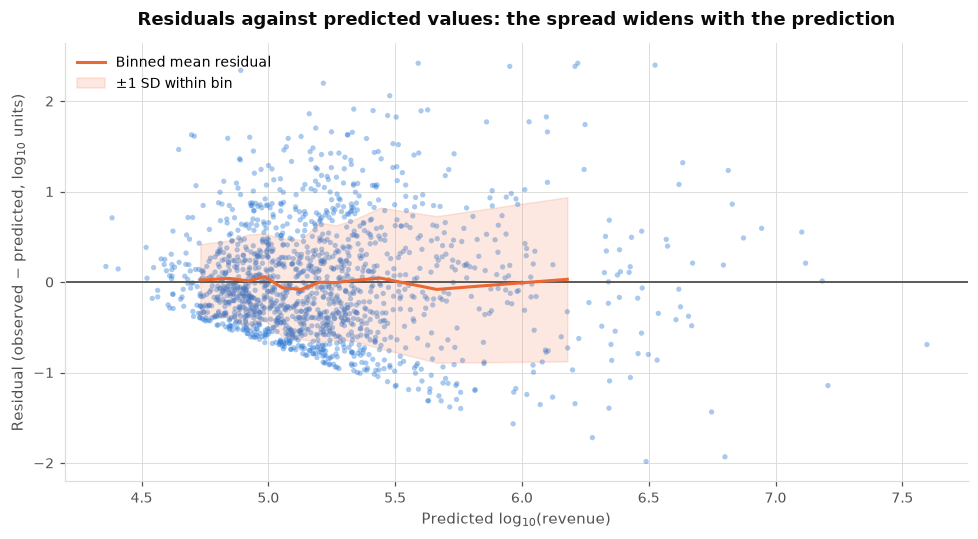

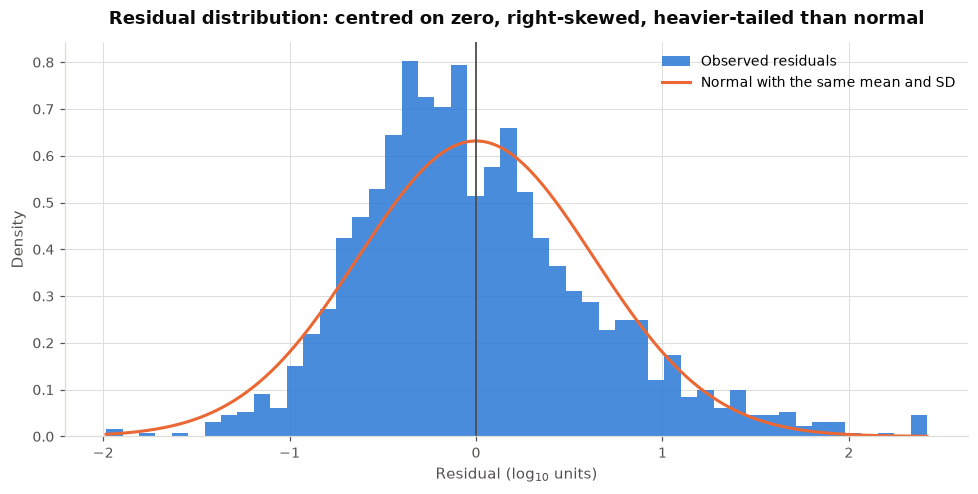

In [10]:
display(plot_residuals_vs_predicted(errors))
display(plot_residual_distribution(errors["residual"]))

In [11]:
from scipy.stats import jarque_bera, spearmanr, ttest_1samp

centring_test = ttest_1samp(errors["residual"], 0)
normality_test = jarque_bera(errors["residual"])
spread_correlation = spearmanr(errors["predicted"], errors["absError"])

print(f"Mean residual              : {errors['residual'].mean():+.6f}")
print(f"Median residual            : {errors['residual'].median():+.4f}")
print(f"t-test that the mean is 0  : t = {centring_test.statistic:+.3f}, p = {centring_test.pvalue:.3f}")
print(f"Jarque-Bera normality test : stat = {normality_test.statistic:.1f}, p = {normality_test.pvalue:.3g}")
print(f"Spearman(predicted, |error|): {spread_correlation.statistic:+.3f}, p = {spread_correlation.pvalue:.3g}")
print()

prediction_quintile = pd.qcut(errors["predicted"], 5, labels=[f"Q{i}" for i in range(1, 6)])
display(
    errors.groupby(prediction_quintile, observed=True)
    .agg(Games=("residual", "size"), **{
        "Mean residual": ("residual", "mean"),
        "SD of residuals": ("residual", "std"),
        "MAE": ("absError", "mean"),
    })
    .round(3)
)

Mean residual              : -0.000587
Median residual            : -0.0878
t-test that the mean is 0  : t = -0.036, p = 0.971
Jarque-Bera normality test : stat = 155.3, p = 1.87e-34
Spearman(predicted, |error|): +0.303, p = 4.02e-33



,Games,Mean residual,SD of residuals,MAE
predicted,,,,
Q1,300,0.026,0.427,0.308
Q2,300,0.017,0.506,0.413
Q3,300,-0.058,0.604,0.501
Q4,300,0.014,0.673,0.555
Q5,300,-0.001,0.859,0.678


**Results and interpretation.** The four questions the assignment poses are
answered in turn.

**Are the residuals centred around zero?** Yes. The mean residual is
$-0.0006$ log units and a one-sample t-test gives $p = 0.971$, so there is no
evidence of overall bias. The median is $-0.088$, and the gap between a mean of
zero and a negative median is the first sign of right skew: most predictions are
slightly too high, and a minority are far too low.

**Do the residuals show systematic patterns?** Not in their *level*. The binned
mean residual in the first figure stays flat along the zero line across the
whole range of predictions, so the model is not systematically over- or
under-predicting in any region of its own output. The systematic behaviour is in
the *spread*, not the centre.

**Is there evidence of heteroscedasticity?** **Yes, and it is unambiguous.**
The Spearman correlation between the prediction and the absolute error is
$+0.303$ with $p \approx 4 \times 10^{-33}$, and the quintile table makes the
size of the effect concrete: the standard deviation of the residuals doubles
from **0.427** in the lowest fifth of predictions to **0.859** in the highest.
MAE rises correspondingly from 0.308 to 0.678.

This violates the constant-variance assumption behind ordinary least squares.
The coefficient estimates remain unbiased, but their standard errors are
understated, so any inference drawn from them would be over-confident. It also
means a single error figure such as MAE describes no part of the data well: it
overstates the error for cheap, low-revenue titles and understates it for the
expensive ones.

**Is there a sector more likely to have high error?** Yes — examined in the
subgroup analysis below.

The residual distribution is centred and unimodal but not normal. Jarque-Bera
returns $p \approx 2 \times 10^{-34}$, and the fitted normal curve sits visibly
below the observed peak and above the shoulders. Skewness is $+0.66$ and excess
kurtosis $+0.85$: a right tail of large under-predictions, and slightly heavier
tails than a normal distribution. Note that this is **after** the log transform;
the same analysis on raw dollars would have been dominated by a handful of games.

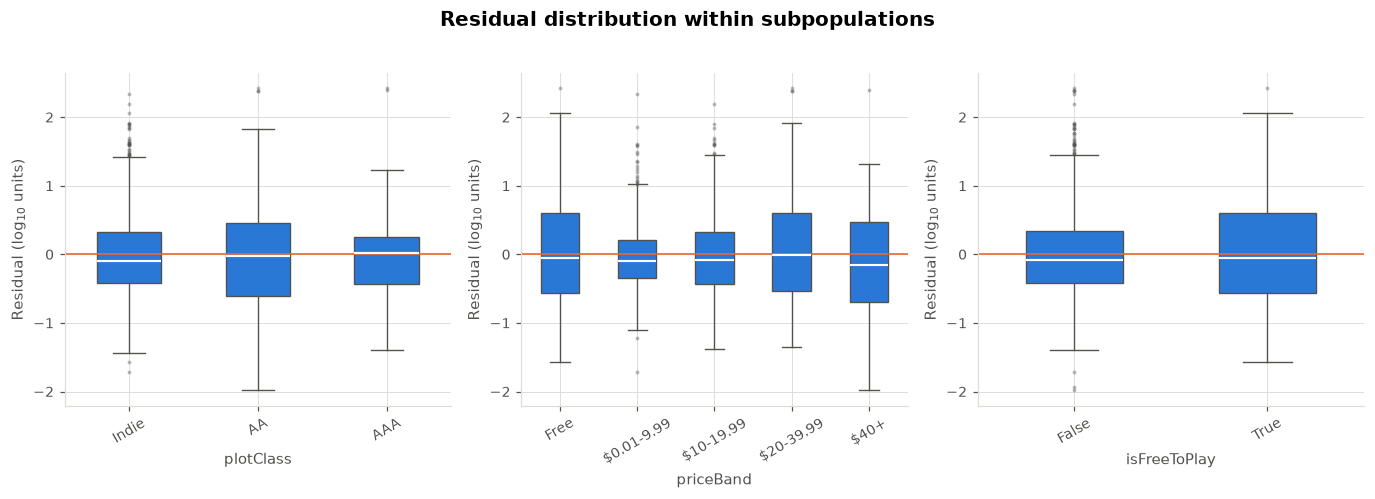

,Variable,Level,Games,Mean residual,SD,MAE
0,plotClass,Indie,1302,-0.001,0.600,0.472
1,plotClass,AA,146,-0.003,0.842,0.654
2,plotClass,AAA,52,0.006,0.728,0.507
3,priceBand,Free,85,-0.006,0.826,0.663
4,priceBand,$0.01-9.99,417,-0.011,0.500,0.376
5,priceBand,$10-19.99,629,-0.015,0.571,0.456
6,priceBand,$20-39.99,304,0.072,0.790,0.642
7,priceBand,$40+,65,-0.118,0.791,0.633
8,isFreeToPlay,False,1415,-0.000,0.618,0.481
9,isFreeToPlay,True,85,-0.006,0.826,0.663


In [12]:
display(plot_error_by_subgroup(errors, ["plotClass", "priceBand", "isFreeToPlay"]))

subgroup_rows = []
for column in ["plotClass", "priceBand", "isFreeToPlay", "selfPublished"]:
    grouped = errors.groupby(column, observed=True)
    for level, group in grouped:
        subgroup_rows.append({
            "Variable": column,
            "Level": str(level),
            "Games": len(group),
            "Mean residual": round(group["residual"].mean(), 3),
            "SD": round(group["residual"].std(), 3),
            "MAE": round(group["absError"].mean(), 3),
        })

errors["reviewScoreMissing"] = errors["reviewScore"].isna()
for level, group in errors.groupby("reviewScoreMissing"):
    subgroup_rows.append({
        "Variable": "reviewScoreMissing",
        "Level": str(level),
        "Games": len(group),
        "Mean residual": round(group["residual"].mean(), 3),
        "SD": round(group["residual"].std(), 3),
        "MAE": round(group["absError"].mean(), 3),
    })

pd.DataFrame(subgroup_rows)

**Which sector carries the highest error?** Three subpopulations stand out, and
the third is the most interesting because it is an artefact of a decision made
in chapter 1.

**Free-to-play titles.** MAE of **0.663** against 0.481 for paid games — roughly
38% worse. The explanation is structural rather than statistical: for these 85
games the listed price is zero and carries no information about how the title
actually monetises. The feature set contains nothing about in-game purchases, so
the model is predicting revenue for a business model it cannot observe.

**Expensive titles.** Error is lowest in the `$0.01–9.99` band (MAE 0.376) and
rises to 0.642 in `$20–39.99` and 0.633 above `$40`. Cheap games occupy a narrow
revenue range and are easy to place; expensive ones span everything from niche
failures to global hits.

**Games whose review score was missing.** This subgroup shows a mean residual of
**+0.300** — the only subpopulation with a clearly biased centre rather than
merely a wider spread. The model **systematically under-predicts these 99 games
by a factor of two**.

The mechanism is traceable. The pipeline imputes the median review score for
these rows, which implicitly treats them as typical. Assignment 1 established
that they are not: games with no review score had a *median revenue of $267,621
against $101,261* for scored games. Median imputation therefore assigns an
average-looking value to a group that is systematically above average, and the
model under-predicts them as a direct consequence.

This is a self-inflicted error, and naming it as such matters: it is not a
property of the data but of the imputation strategy chosen in section 1.5. A
missingness indicator would let the model learn that an absent review score is
itself informative. That is a concrete improvement, carried to chapter 5.

### 2.2 Error as a Function of Features

**Method.** Each numeric feature is plotted against the signed residual and
against the absolute error. The signed plots reveal regions where the model is
biased; the absolute plots reveal regions where it is merely imprecise. The
overlaid line is the mean within equal-count bins of the feature.

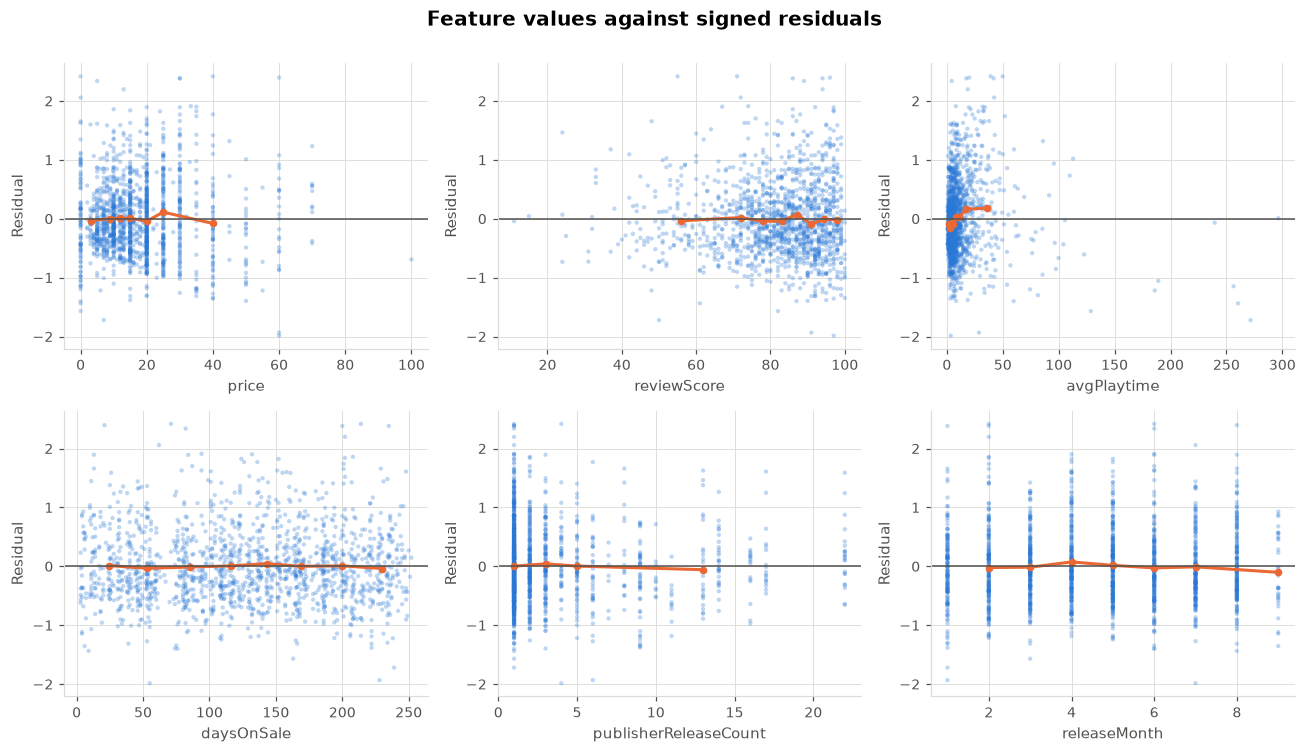

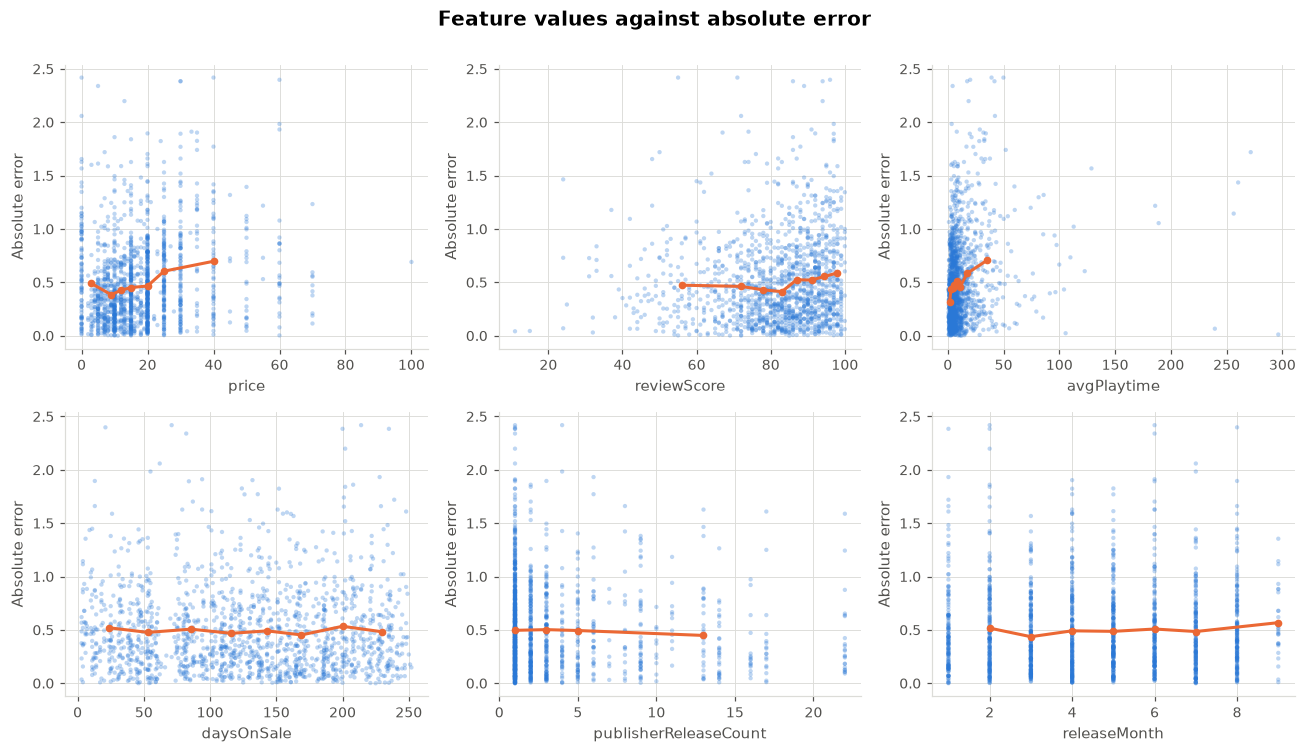

In [13]:
display(plot_feature_error_grid(errors, NUMERIC_FEATURES, "residual",
                                "Feature values against signed residuals"))
display(plot_feature_error_grid(errors, NUMERIC_FEATURES, "absError",
                                "Feature values against absolute error"))

In [14]:
feature_error_rows = []
for feature in NUMERIC_FEATURES:
    subset = errors[[feature, "residual", "absError"]].dropna()
    feature_error_rows.append({
        "Feature": feature,
        "Spearman vs residual": round(spearmanr(subset[feature], subset["residual"]).statistic, 3),
        "Spearman vs |error|": round(spearmanr(subset[feature], subset["absError"]).statistic, 3),
    })
pd.DataFrame(feature_error_rows)

,Feature,Spearman vs residual,Spearman vs |error|
0,price,-0.005,0.176
1,reviewScore,-0.018,0.103
2,avgPlaytime,0.140,0.216
3,daysOnSale,0.008,-0.027
4,publisherReleaseCount,0.023,-0.043
5,releaseMonth,-0.009,0.021


**Results and interpretation.** The signed residuals are close to flat against
every feature — no correlation exceeds $|0.14|$ — which confirms the finding
from 2.1 that the model has no systematic directional bias in feature space.
Against absolute error the picture is different, and it separates the ten
features into two groups.

**Features that predict the size of the error:**

| Feature | ρ vs residual | ρ vs \|error\| |
|---|---|---|
| `avgPlaytime` | +0.140 | **+0.216** |
| `price` | −0.005 | **+0.176** |
| `reviewScore` | −0.018 | +0.103 |

**Features that do not:** `daysOnSale` (−0.027), `publisherReleaseCount`
(−0.043) and `releaseMonth` (+0.021) are all effectively zero.

`avgPlaytime` carries the strongest relationship of the ten, and it is the only
feature with a visible relationship to the *signed* residual as well
($+0.140$): games played for longer tend to be under-predicted, and to be
predicted less accurately. A plausible reading is that high playtime marks
live-service and open-ended titles whose commercial performance depends on
retention mechanics the feature set does not capture — but the data here
supports the association, not the mechanism, and distinguishing them would
require genre and monetisation data.

The flatness of `daysOnSale` is worth noting because it is a *negative* result
with a known cause. Assignment 1 found that revenue does not vary with exposure
in this sample, because selecting the top 1,500 earners removes the relationship
between how long a game has been on sale and how much it earned. The model
inherits that: exposure predicts neither the revenue nor the error.

**Conclusion.** Error concentrates where the price is high and playtime is long,
and is unrelated to when a game was released or how prolific its publisher is.

### 2.3 Analysis of Extreme Errors

**Method.** The largest 5% of absolute errors — 75 games — are isolated and
examined both as a group and individually, and each is attributed to one of the
three causes the assignment names: data quality, model limitation, or a rare
case.

Threshold          : |residual| >= 1.265 log units (a factor of 18.4 in dollars)
Games identified   : 75
Share of total absolute error: 16.5%
Direction          : 60 under-predicted, 15 over-predicted


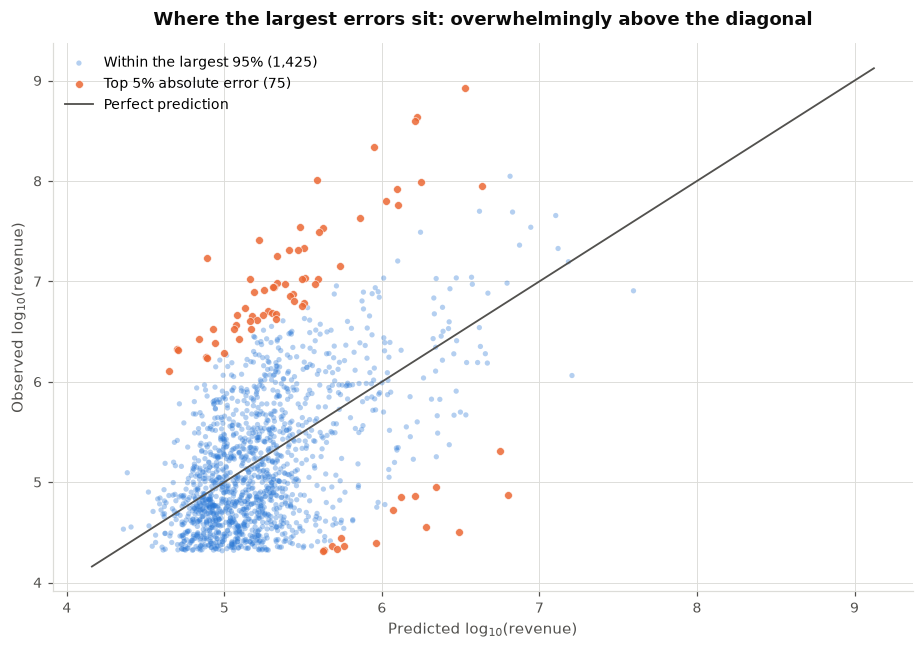

In [15]:
extreme_threshold = errors["absError"].quantile(0.95)
extreme_errors = errors[errors["absError"] >= extreme_threshold]

print(f"Threshold          : |residual| >= {extreme_threshold:.3f} log units "
      f"(a factor of {10 ** extreme_threshold:.1f} in dollars)")
print(f"Games identified   : {len(extreme_errors)}")
print(f"Share of total absolute error: {extreme_errors['absError'].sum() / errors['absError'].sum():.1%}")
print(f"Direction          : {(extreme_errors['residual'] > 0).sum()} under-predicted, "
      f"{(extreme_errors['residual'] < 0).sum()} over-predicted")

display(plot_extreme_errors(errors, extreme_threshold))

In [16]:
comparison = pd.DataFrame({
    "Top 5% by error": [
        extreme_errors["plotClass"].eq("Indie").mean(),
        extreme_errors["isFreeToPlay"].mean(),
        extreme_errors["reviewScore"].isna().mean(),
        extreme_errors["price"].median(),
        extreme_errors["avgPlaytime"].median(),
        extreme_errors["revenue"].median(),
    ],
    "All games": [
        errors["plotClass"].eq("Indie").mean(),
        errors["isFreeToPlay"].mean(),
        errors["reviewScore"].isna().mean(),
        errors["price"].median(),
        errors["avgPlaytime"].median(),
        errors["revenue"].median(),
    ],
}, index=["Indie share", "Free-to-play share", "Review score missing share",
          "Median price (USD)", "Median playtime (hours)", "Median revenue (USD)"])
display(comparison.round(3))

largest = extreme_errors.nlargest(10, "absError")[
    ["name", "revenue", "predicted", "residual", "price", "reviewScore", "avgPlaytime", "plotClass"]
].copy()
largest["predicted revenue (USD)"] = (10 ** largest["predicted"]).round(0)
largest[["name", "revenue", "predicted revenue (USD)", "residual", "price",
         "reviewScore", "avgPlaytime", "plotClass"]]

,Top 5% by error,All games
Indie share,0.707,0.868
Free-to-play share,0.107,0.057
Review score missing share,0.107,0.066
Median price (USD),19.990,14.990
Median playtime (hours),16.869,6.763
Median revenue (USD),5478333.000,109053.000


,name,revenue,predicted revenue (USD),residual,price,reviewScore,avgPlaytime,plotClass
1451,HELLDIVERS™ 2,435635596.0,1660249.0,2.418950,39.99,71.0,39.205960,AAA
1455,The First Descendant,102244808.0,389948.0,2.418635,0.00,55.0,49.870230,AA
1450,Black Myth: Wukong,837793356.0,3349118.0,2.398206,59.99,96.0,20.065041,AAA
1453,Sons Of The Forest,217017892.0,895292.0,2.384531,29.99,86.0,17.341205,AA
1452,Palworld,392328553.0,1619090.0,2.384379,29.99,94.0,41.840761,AA
1477,Chained Together,17039291.0,77863.0,2.340118,4.99,89.0,4.298189,Indie
1470,Supermarket Simulator,26020639.0,164755.0,2.198480,12.99,94.0,18.640685,Indie
1466,Once Human,34530561.0,301095.0,2.059500,0.00,72.0,42.261045,Indie
885,Demon Slayer -Kimetsu no Yaiba- Sweep the Board!,32016.0,3087107.0,-1.984185,59.99,97.0,3.453795,AA
433,Combat Mission: Final Blitzkrieg,73845.0,6319497.0,-1.932361,59.99,91.0,28.695101,AA


**Results.** The threshold falls at 1.265 log units, meaning every game in this
group is mispriced by a **factor of at least 18**. Together these 75 games carry
**16.5% of all absolute error** in the dataset.

The direction is strongly asymmetric: **60 are under-predicted and only 15 are
over-predicted.** The scatter shows this directly — the marked points sit
overwhelmingly above the diagonal.

The group differs from the dataset on every dimension measured. Its median
revenue is **$5.48 million against $109,053** overall — a factor of 50. It is
less Indie (70.7% against 86.8%), more free-to-play (10.7% against 5.7%), more
often missing a review score (10.7% against 6.6%), more expensive ($19.99 against
$14.99) and much longer played (16.9 hours against 6.8).

**Interpretation — attributing the causes.** The three categories the assignment
names apply to identifiably different parts of this group.

**Model limitation — the dominant cause, covering the 60 under-predictions.**
The largest errors are the year's biggest hits: *HELLDIVERS 2* earned $436M
against a prediction of $1.66M, *Black Myth: Wukong* $838M against $3.35M. These
are not strange observations; they are the most important games of 2024, and the
model places them two and a half orders of magnitude too low.

Two mechanisms combine. The first is structural: a linear model predicts near
the centre of the training distribution, and with a median revenue of $109,053
no additive combination of price, playtime and studio class can reach $838M. The
second is informational: the features contain nothing about marketing spend,
franchise recognition, wishlist counts or word-of-mouth — the factors that
actually separate a hit from a competent release. **The model is not wrong about
these games so much as blind to them.**

**Rare and exceptional cases — the 15 over-predictions.** These are more
interesting, because they are failures in the opposite direction. *Demon Slayer:
Sweep the Board!* earned **$32,016** against a prediction of $3.09M, and *Combat
Mission: Final Blitzkrieg* earned **$73,845** against $6.32M. Both are priced at
$59.99, both review well (97 and 91), and both are AA titles. The model sees an
expensive, well-reviewed release from an established studio and predicts
accordingly. These are plausibly niche or licensed products with a small
addressable audience — but the dataset cannot confirm that, and genre or
regional data would be needed to test it. They are labelled rare cases because
they are genuinely atypical, not because the model is misapplied.

**Data quality — a contributing factor, not a primary one.** Free-to-play games
and games with missing review scores are both roughly twice as frequent in this
group as in the dataset. For the free-to-play titles the issue is a genuine gap
in the data: revenue arrives through a channel the features do not describe. For
the missing review scores the issue is the imputation choice identified in 2.1.
Neither explains the blockbusters, which have complete data.

**Conclusion.** The extreme errors are not corrupted records to be cleaned away.
They are the commercially most significant games in the dataset, and the model
fails on them because the features do not contain what makes a hit a hit. This
is a limitation of the problem formulation as much as of the model, and no
change of algorithm will fully repair it — a point tested directly in chapter 3.

### 2.4 Statistical Properties of Errors

**Method.** The assignment asks for the mean absolute error, the standard
deviation of the residuals, and their skewness and kurtosis, with the
interpretation that heavy tails may indicate instability and skew may indicate
systematic bias.

In [17]:
display(residual_statistics(errors["residual"]))

print(f"Median absolute error as a dollar factor : "
      f"x{10 ** errors['absError'].median():.2f}")
print(f"90th percentile of absolute error        : "
      f"x{10 ** errors['absError'].quantile(0.90):.1f}")

,Value
Count,1500.0000
Mean residual,-0.0006
Median residual,-0.0878
MAE,0.4910
Standard deviation,0.6315
Skewness,0.6643
Excess kurtosis,0.8485


Median absolute error as a dollar factor : x2.49
90th percentile of absolute error        : x10.0


**Results and interpretation.**

| Statistic | Value | What it says |
|---|---|---|
| MAE | 0.491 | The typical prediction is out by about half a log unit |
| Standard deviation | 0.632 | Wider than the MAE, reflecting the tail |
| Skewness | +0.664 | Moderate right skew |
| Excess kurtosis | +0.848 | Mildly heavy tails |
| Mean residual | −0.0006 | No overall bias |

**On the MAE.** Half a log unit is best understood back on the dollar scale: the
median absolute error corresponds to a factor of **2.5**, and the 90th percentile
to a factor of **10**. A typical prediction from this model is wrong by a
factor of two and a half, and one prediction in ten is wrong by nearly a factor
of ten. That is the honest summary of its accuracy.

**On the skewness.** The assignment notes that skew may indicate systematic
bias. Here it does *not*, and the distinction matters. The mean residual is zero
to four decimal places and the t-test is emphatically non-significant, so there
is no bias in the usual sense. The $+0.664$ skew instead reflects an **asymmetry
in the shape of the failures**: the model's mistakes are not symmetric because
the phenomenon is not. A game can earn a hundred times more than expected —
*Black Myth: Wukong* did — but it cannot earn a hundred times less than a
prediction that already sits near the bottom of the observed range. The floor
is hard and the ceiling is not.

**On the kurtosis.** An excess kurtosis of $+0.85$ is mild. For comparison, the
model in section 1.3 that included `copiesSold` produced a kurtosis of 27.7, and
the raw revenue variable in Assignment 1 had a skew of 22.9. The transform and
the feature choice together have produced an error distribution that is only
slightly heavier-tailed than normal, which is a considerably better-behaved
starting point for the model comparison than the raw scale would have given.

The practical implication is that **the errors are stable enough for the mean to
be a meaningful summary**, but not so well behaved that it is the only summary
worth reporting. Chapter 3 therefore reports MAE alongside RMSE, which weights
the tail more heavily, and the two will diverge where a model handles the
extremes differently.

**Conclusion.** The residuals are unbiased, moderately right-skewed and mildly
heavy-tailed. The skew is a property of the phenomenon rather than a defect of
the model, and the mild kurtosis confirms that the log transform chosen in
section 0.3 did the work it was intended to do.

## 3. Regression Models

*Not yet written.* Linear Regression, Decision Tree and Random Forest compared on a common feature set, followed by the critical discussion and the choice of a preferred model.

## 4. Classification Error Analysis

*Not yet written.* Confusion matrix, false positives and negatives, probability-based analysis, error as a function of features, threshold sensitivity, and ROC/AUC with the Matthews correlation coefficient.

## 5. Final Reflection

*Not yet written.* The four closing questions, answered explicitly.